# Diffusion coordinates on a toroidal helix

This notebook gives a small geometric example of what diffusion coordinates are doing.

The observed data form a **one-dimensional closed manifold embedded in** $\mathbb{R}^3$: a toroidal helix. The points are sampled uniformly in **intrinsic arc length**, so the example is not complicated by non-uniform sampling density.

The notebook asks two questions:

1. What do the leading diffusion coordinates look like?
2. How do distances in the diffusion representation relate to the known geodesic distance along the helix?

PCA and graph paths are deliberately left out for now. They can be added later without changing the basic construction.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr

np.random.seed(0)

## 1. Sample the toroidal helix uniformly in arc length

We use

$$
X(t)=\Big((R+r\cos(nt))\cos t,\; (R+r\cos(nt))\sin t,\; r\sin(nt)\Big),
\qquad 0\leq t<2\pi.
$$

Although $X(t)$ has three observed coordinates, the manifold itself is one-dimensional and closed.

Uniform spacing in the parameter $t$ is **not** uniform spacing along the curve because the speed $\|X'(t)\|$ varies with $t$. Here

$$
\|X'(t)\| = \sqrt{(R+r\cos(nt))^2 + (nr)^2}.
$$

We therefore integrate this speed to obtain arc length $s(t)$ and invert that map so that the sampled points are equally spaced in $s$. The endpoint $2\pi$ is excluded because it is the same physical point as $0$.

In [ ]:
def toroidal_helix_uniform_arclength(R, r, n, N, integration_grid=100_000):
    """Sample a closed toroidal helix at approximately equal arc-length intervals.

    Returns
    -------
    X : (N, 3) array
        Points on the helix.
    t : (N,) array
        Parameter values corresponding to the sampled points.
    s : (N,) array
        Intrinsic arc-length coordinate in [0, L).
    L : float
        Total length of the closed curve.
    """
    # Fine parameter grid used only to construct the arc-length map s(t).
    t_grid = np.linspace(0.0, 2.0 * np.pi, integration_grid)

    speed = np.sqrt((R + r * np.cos(n * t_grid))**2 + (n * r)**2)

    s_grid = np.concatenate([[0.0], cumulative_trapezoid(speed, t_grid)])
    total_length = s_grid[-1]

    # Uniform intrinsic locations. endpoint=False avoids duplicating t=0 and t=2π.
    s = np.linspace(0.0, total_length, N, endpoint=False)
    t = np.interp(s, s_grid, t_grid)

    x = (R + r * np.cos(n * t)) * np.cos(t)
    y = (R + r * np.cos(n * t)) * np.sin(t)
    z = r * np.sin(n * t)

    noise = np.random.normal(scale=0.1, size=(N, 3))

    X = np.column_stack([x, y, z])
    X += noise
    return X, t, s, total_length


R_MAJOR = 3.0
R_MINOR = 1.0
N_WINDINGS = 10
N_SAMPLES = 700

X, t, s, L = toroidal_helix_uniform_arclength(R_MAJOR, R_MINOR, N_WINDINGS, N_SAMPLES)

phase = s / L

print(f"Number of observations: {len(X)}")
print(f"Total intrinsic length: {L:.4f}")
print(f"Arc-length spacing: {s[1] - s[0]:.4f}")

Number of observations: 700
Total intrinsic length: 65.7363
Arc-length spacing: 0.0939


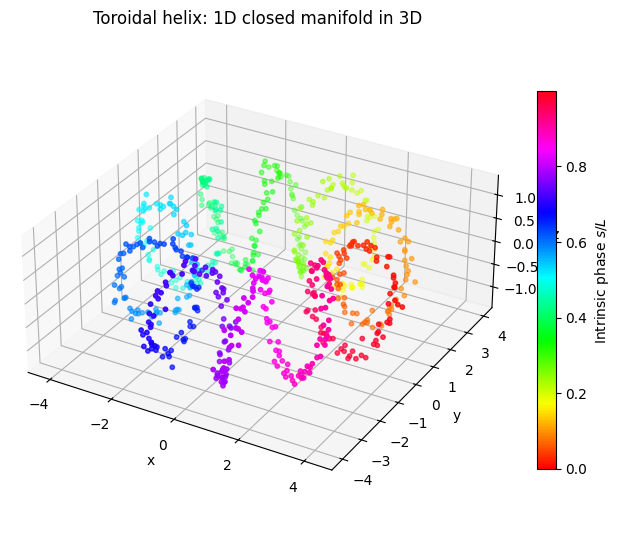

In [ ]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=phase, cmap="hsv", s=10)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Toroidal helix: 1D closed manifold in 3D")
ax.set_box_aspect([1, 1, 0.45])
fig.colorbar(sc, ax=ax, shrink=0.7, label="Intrinsic phase $s/L$")
plt.show()

## 2. Diffusion map

The affinity matrix is

$$
W_{ij}=\exp\!\left(-\frac{\|X_i-X_j\|^2}{\varepsilon}\right).
$$

We use the same $\alpha=1$ normalisation as in the main methodology. The trivial constant eigenvector is discarded, and the remaining eigenvectors are weighted by their eigenvalues to form diffusion coordinates.

In [ ]:
def diffusion_map(data, eps, alpha=1.0, n_components=5, diffusion_time=1):
    """Dense diffusion-map implementation for small toy examples."""
    Dsq = squareform(pdist(data)**2)
    W = np.exp(-Dsq / eps)

    q = W.sum(axis=1)
    W_alpha = W / np.outer(q**alpha, q**alpha)

    d_alpha = W_alpha.sum(axis=1)
    inv_sqrt_d = 1.0 / np.sqrt(d_alpha)
    S = inv_sqrt_d[:, None] * W_alpha * inv_sqrt_d[None, :]

    eigenvalues, eigenvectors = np.linalg.eigh(S)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Right eigenvectors of the row-stochastic operator.
    phi = inv_sqrt_d[:, None] * eigenvectors

    lambdas = eigenvalues[1:n_components + 1]
    Psi = phi[:, 1:n_components + 1] * lambdas**diffusion_time

    return {"evals": eigenvalues, "phi": phi, "Psi": Psi, "W": W, "degrees": q, "eps": eps, "alpha": alpha}

### Bandwidth diagnostic

For a one-dimensional manifold, the small-bandwidth kernel mass scales approximately as $\varepsilon^{1/2}$. Therefore a region where the log-log slope is near $1/2$ is a useful diagnostic for the local geometric regime.

The chosen value below is kept explicit so it can be changed later.

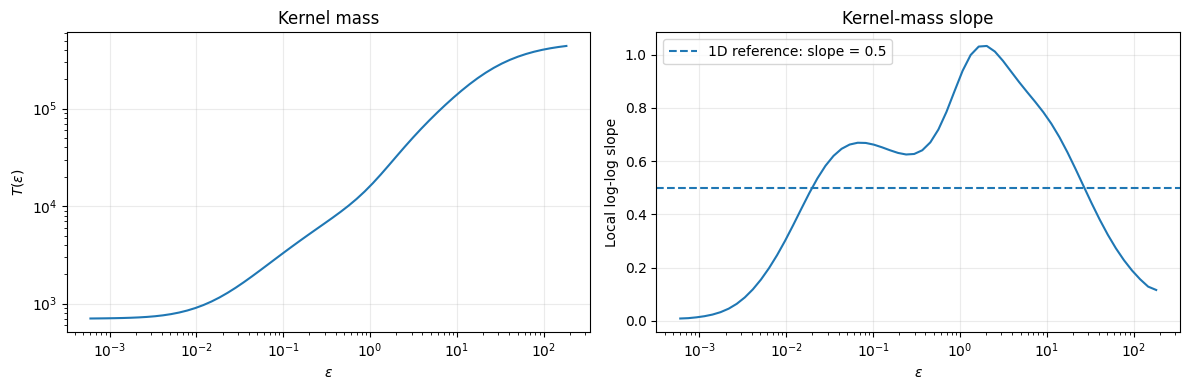

In [21]:
def kernel_mass_diagnostic(X, n_eps=60):
    Dsq = squareform(pdist(X)**2)
    D_no_diag = Dsq.copy()
    np.fill_diagonal(D_no_diag, np.inf)

    nearest_sq = np.median(np.min(D_no_diag, axis=1))
    median_sq = np.median(Dsq[np.triu_indices_from(Dsq, k=1)])
    eps_grid = np.logspace(np.log10(nearest_sq) - 1.5, np.log10(median_sq) + 1.0, n_eps)
    kernel_mass = np.array([np.exp(-Dsq / eps).sum() for eps in eps_grid])
    slope = np.gradient(np.log(kernel_mass), np.log(eps_grid))

    return eps_grid, kernel_mass, slope


eps_grid, kernel_mass, slope = kernel_mass_diagnostic(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(eps_grid, kernel_mass)
axes[0].set_xlabel(r"$\varepsilon$")
axes[0].set_ylabel(r"$T(\varepsilon)$")
axes[0].set_title("Kernel mass")
axes[0].grid(alpha=0.25)

axes[1].semilogx(eps_grid, slope)
axes[1].axhline(0.5, linestyle="--", label="1D reference: slope = 0.5")
axes[1].set_xlabel(r"$\varepsilon$")
axes[1].set_ylabel("Local log-log slope")
axes[1].set_title("Kernel-mass slope")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [22]:
EPS = 0.1

In [ ]:
diff = diffusion_map(X, eps=EPS, alpha=1.0, n_components=5, diffusion_time=1)

Psi_full = diff["Psi"]
Psi = Psi_full[:, :2]
evals = diff["evals"]

print("Leading eigenvalues:")
print(np.round(evals[:8], 6))

Leading eigenvalues:
[1.       0.999807 0.999793 0.999214 0.999187 0.998226 0.998185 0.9969  ]


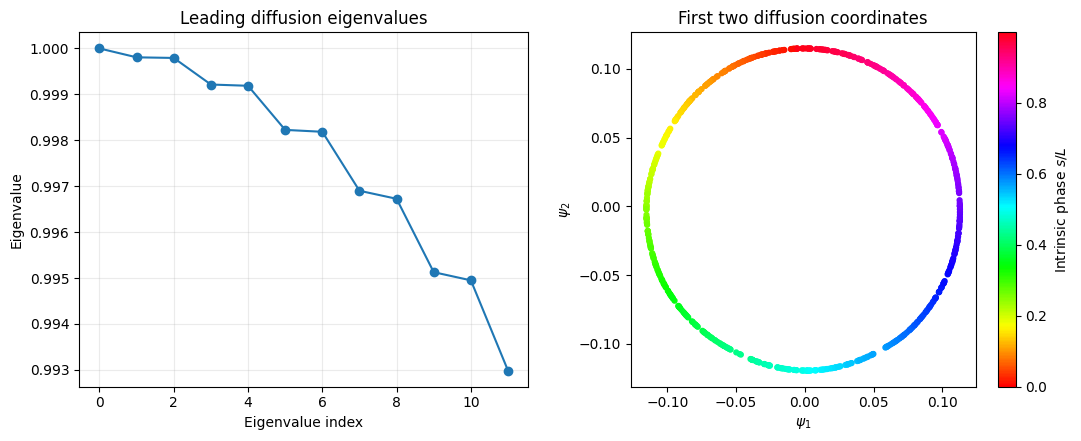

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(evals[:12], marker="o")
axes[0].set_xlabel("Eigenvalue index")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_title("Leading diffusion eigenvalues")
axes[0].grid(alpha=0.25)

sc = axes[1].scatter(Psi[:, 0], Psi[:, 1], c=phase, cmap="hsv", s=12)
axes[1].set_xlabel(r"$\psi_1$")
axes[1].set_ylabel(r"$\psi_2$")
axes[1].set_title("First two diffusion coordinates")
axes[1].set_aspect("equal", adjustable="box")
fig.colorbar(sc, ax=axes[1], label="Intrinsic phase $s/L$")

plt.tight_layout()
plt.show()

The original curve winds repeatedly through three-dimensional space, while the first two diffusion coordinates recover an approximately circular representation of its intrinsic closed-loop structure.

The two coordinates should be interpreted together: for a closed one-dimensional manifold, a sine/cosine-like eigenfunction pair provides a continuous global representation without introducing an artificial cut.

## 3. Ground-truth geodesic distance on the helix

Because $s_i$ is the intrinsic arc-length coordinate and the curve is closed with total length $L$, the geodesic distance between two sampled points is

$$
d_{\mathcal M}(i,j)
=\min\bigl(|s_i-s_j|,\; L-|s_i-s_j|\bigr).
$$

This is the length of the shorter of the two arcs joining the points.

The arc-length coordinates themselves were obtained by high-resolution numerical quadrature of the known analytic speed $\|X'(t)\|$.

In [18]:
def create_pairs(n_samples, n_pairs=5000, seed=0):
    """Sample unique unordered pairs without self-pairs."""
    i, j = np.triu_indices(n_samples, k=1)
    all_pairs = np.column_stack([i, j])

    rng = np.random.default_rng(seed)
    n_pairs = min(n_pairs, len(all_pairs))
    selected = rng.choice(len(all_pairs), size=n_pairs, replace=False)
    return all_pairs[selected]


def intrinsic_dist_helix(s, total_length, pairs):
    """Geodesic distance along a closed curve from its arc-length coordinates."""
    ds = np.abs(s[pairs[:, 0]] - s[pairs[:, 1]])
    return np.minimum(ds, total_length - ds)


def diffusion_distance(Psi, pairs):
    """Euclidean endpoint distance in the retained diffusion coordinates."""
    diffs = Psi[pairs[:, 0]] - Psi[pairs[:, 1]]
    return np.linalg.norm(diffs, axis=1)


pairs = create_pairs(len(X), n_pairs=5000, seed=0)

d_geo = intrinsic_dist_helix(s, L, pairs)
D_diff = diffusion_distance(Psi, pairs)

print(f"Maximum possible helix geodesic distance L/2: {L / 2:.4f}")
print(f"Number of sampled pairs: {len(pairs)}")

Maximum possible helix geodesic distance L/2: 32.8681
Number of sampled pairs: 5000


## 4. Diffusion distance versus intrinsic geodesic distance

These two distances should **not** be expected to be numerically equal.

If the first two diffusion coordinates form an ideal circle, then the Euclidean distance between two embedded points is a **chord**, whereas the geodesic distance is an **arc length**. The relationship is therefore nonlinear over large separations, but approximately linear for nearby points.

To compare geometry rather than arbitrary coordinate scale, both distances are normalised by their natural maximum in the sampled representation.

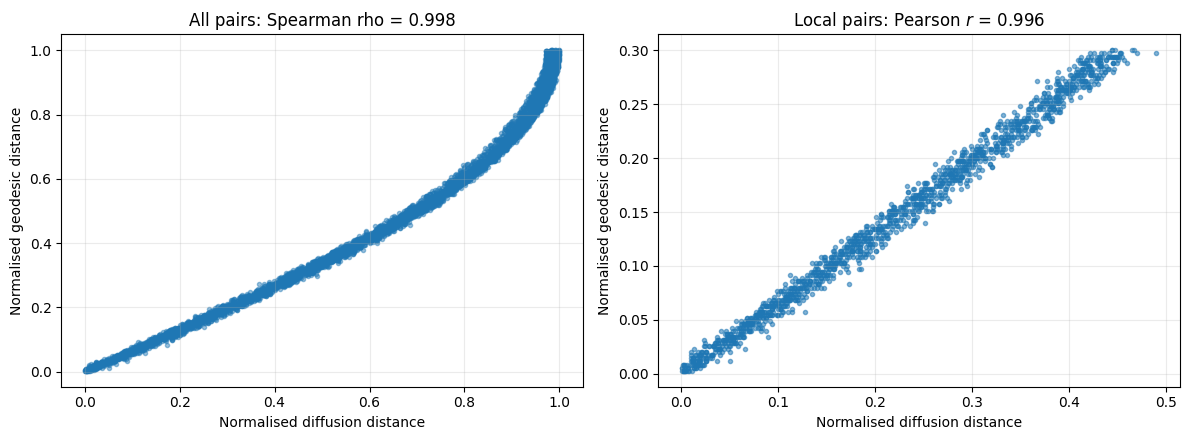

Spearman correlation, all pairs: 0.9981
Pearson correlation, local pairs: 0.9956


In [ ]:
# Normalise to [0, 1] for a scale-free geometric comparison.
d_geo_norm = d_geo / (L / 2.0)
D_diff_norm = D_diff / D_diff.max()

# Local pairs: less than 30% of the maximum possible geodesic separation.
local_mask = d_geo_norm < 0.30

spearman_all = spearmanr(D_diff_norm, d_geo_norm).statistic
pearson_local = pearsonr(D_diff_norm[local_mask], d_geo_norm[local_mask]).statistic

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(D_diff_norm, d_geo_norm, s=9, alpha=0.45)
axes[0].set_xlabel("Normalised diffusion distance")
axes[0].set_ylabel("Normalised geodesic distance")
axes[0].set_title(f"All pairs: Spearman rho = {spearman_all:.3f}")
axes[0].grid(alpha=0.25)

axes[1].scatter(D_diff_norm[local_mask], d_geo_norm[local_mask], s=9, alpha=0.55)
axes[1].set_xlabel("Normalised diffusion distance")
axes[1].set_ylabel("Normalised geodesic distance")
axes[1].set_title(f"Local pairs: Pearson $r$ = {pearson_local:.3f}")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Spearman correlation, all pairs: {spearman_all:.4f}")
print(f"Pearson correlation, local pairs: {pearson_local:.4f}")

## Interpretation

The example is intended to show three things, and no more:

1. The toroidal helix is geometrically complicated in its observed $\mathbb{R}^3$ coordinates but intrinsically is just a closed one-dimensional curve.
2. The first two diffusion coordinates recover a simple global representation of that closed geometry.
3. Diffusion-space endpoint distances strongly track intrinsic separation. They are not identical to geodesic distances: globally they behave like chord versus arc length, while locally the relationship becomes approximately linear.

A later graph-path section can return to exactly the same data. A local shortest path around the diffusion-space circle will sum small chords and can then be compared with the true arc-length geodesic on the original toroidal helix.

# Part 1.1
### Potentially compare to PCA but not yet.

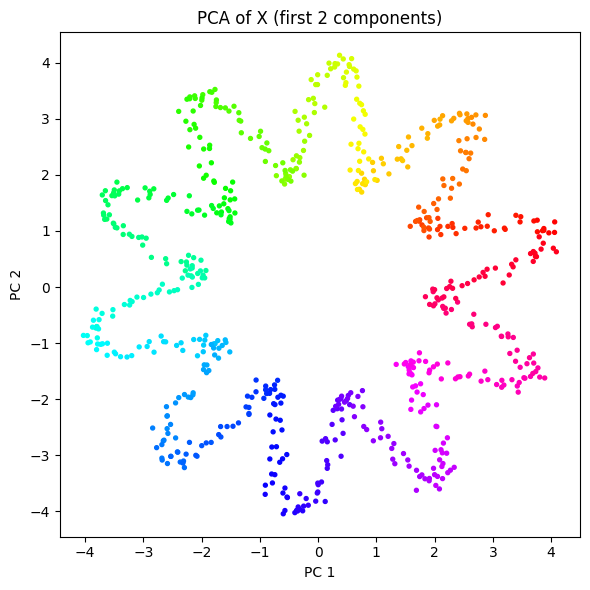

In [25]:
from sklearn.decomposition import PCA
indices = np.arange(len(X))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=indices, cmap="hsv", s=8)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA of X (first 2 components)")
plt.tight_layout()
plt.show()

# Part 2
### Graph paths through diffusion coordinates

In [ ]:
def knn_graph_checks(Psi, k, sample_skip=50, jump_thresh=8.0):
    N = Psi.shape[0]
    A_dist = kneighbors_graph(Psi, n_neighbors=k, mode="distance", include_self=False)
    A_bin  = kneighbors_graph(Psi, n_neighbors=k, mode="connectivity", include_self=False)
    A_dist_sym = A_dist.maximum(A_dist.T); A_bin_sym = A_bin.maximum(A_bin.T)
    n_comp, _ = connected_components(A_bin_sym, directed=False)
    degree = np.asarray(A_bin_sym.sum(1)).ravel()
    edges = A_bin_sym.nnz/2; density = edges/(N*(N-1)/2)
    _, pred = shortest_path(A_dist_sym, directed=False, return_predecessors=True)
    jr = []
    for a in range(1, N, sample_skip):
        for b in range(a+1, N, sample_skip):
            path = reconstruct_path(pred, a, b)
            if path is None or len(path) < 2: continue
            el = np.array([A_dist_sym[path[t], path[t+1]] for t in range(len(path)-1)])  # [C7] renamed t
            med = np.median(el)
            if med > 1e-12: jr.append(el.max()/med)
    jr = np.array(jr); jr95 = np.quantile(jr, 0.95)
    accept = (n_comp == 1) and (density < 0.5) and (jr95 < jump_thresh)   # [C5] real criterion
    return dict(k=k, components=n_comp, mean_degree=degree.mean(), density=density,
                max_edge=A_dist_sym.data.max(), median_edge=np.median(A_dist_sym.data),
                jump95=jr95, status="Accepted" if accept else "Rejected")

rows = [knn_graph_checks(Psi, k) for k in [4, 10]]
graph_df = pd.DataFrame(rows).set_index("k")
print(graph_df.round(4).to_string())
h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)

A_dist = kneighbors_graph(Psi, n_neighbors=10, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

    components  mean_degree  density  max_edge  median_edge  jump95    status
k                                                                            
4            1       4.0371   0.0058    0.0038       0.0016  2.3915  Accepted
10           1      10.2543   0.0147    0.0095       0.0030  2.3043  Accepted


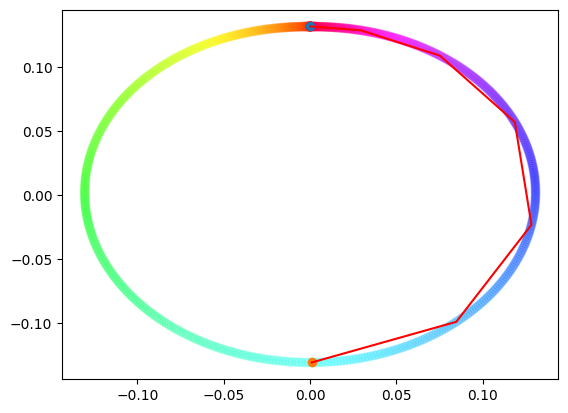

In [ ]:

idx_start = 0
idx_end = 350
idx_graph = graph_path(A_dist_sym, beta=0, V=V, start=idx_start, end=idx_end)

plt.scatter(Psi[:, 0], Psi[:, 1], alpha=0.2, c=indices, cmap='hsv')
plt.scatter(Psi[idx_start, 0], Psi[idx_start, 1])
plt.scatter(Psi[idx_end, 0], Psi[idx_end, 1])
plt.plot(Psi[idx_graph, 0], Psi[idx_graph, 1], color="r")
